# Feature Analysis Code

## Imports

In [ ]:
import pandas as pd
import scipy
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import LeaveOneGroupOut, permutation_test_score
from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score
from sklearn.feature_selection import VarianceThreshold
import networkx as nx
from collections import defaultdict
import seaborn as sns

## Read Extracted Data

In [ ]:
features_df = pd.read_csv("../extracted_features/extracted_features.csv")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
n_participants = len(features_df) // 3
participants_df = features_df.iloc[:n_participants]

features_df.loc[:2]

,participant_id,age,gender,handedness,val_baseline,ar_baseline,round,emotion,emotion_name,erased_pixels,drawing_time,val_start,ar_start,val_end,ar_end,n_strokes,n_undone_strokes,n_eraser_strokes,stroke_total_length,stroke_mean_length,stroke_std_length,stroke_mean_speed,stroke_std_speed,stroke_mean_accel,stroke_std_accel,stroke_mean_pressure,stroke_std_pressure,stroke_pressure_slope,pen_size_used_count,pen_size_mean,pen_size_std,stroke_mean_curvature,stroke_mean_angularity,avg_time_between_strokes,std_time_between_strokes,total_pause_time,pause_ratio,stroke_frequency,stroke_mean_abs_jerk,stroke_speed_zero_cross_rate,pressure_velocity_corr,tilt_x_mean,tilt_y_mean,tilt_x_std,tilt_y_std,tilt_pressure_corr,stroke_mean_straightness,stroke_std_straightness,bbox_width,bbox_height,bbox_area,centroid_x,centroid_y,spatial_spread,ink_density,speed_dominant_freq,speed_dominant_freq_power,stroke_speed_trend,stroke_speed_half_diff,stroke_length_trend,stroke_length_half_diff,pressure_change_bandwidth,pressure_change_median_freq,pressure_change_peaks_per_sec,pressure_change_distance_to_mean,tiltx_change_bandwidth,tiltx_change_median_freq,tiltx_change_peaks_per_sec,tiltx_change_distance_to_mean,tilty_change_bandwidth,tilty_change_median_freq,tilty_change_peaks_per_sec,tilty_change_distance_to_mean,speed_peaks_per_sec,speed_distance_to_mean,trajectory_fractal_dimension,tilt_magnitude_mean,tilt_magnitude_std,tilt_angle_mean,tiltx_trend,tilty_trend,stroke_straightness_trend,bbox_aspect_ratio,bbox_diagonal,bbox_elongation,surface_coverage_ratio,pixel_std_x,pixel_std_y,mean_distance_center,left_right_balance,top_bottom_balance,colors_used_count,mean_hue,std_hue,mean_saturation,std_saturation,mean_brightness,std_brightness,black_ratio,warm_cool_ratio,brightness_range
0,kadd,22,2,2,0.230392,-0.630719,1,1,EXCITEMENT,2925,300.144187,0.519608,0.212418,0.189542,-0.209150,84,1,0,258.891932,3.045787,4.848980,962.544641,511.016062,6.948090e+06,3.442235e+06,0.306292,0.095398,0.000642,2,5.235294,2.156506,0.457213,20.097923,2.565984,7.066338,215.542618,0.718130,0.279865,9.781474e+11,113.565581,0.085469,0.297498,0.010090,0.012162,0.015106,-0.016214,0.732474,0.259776,29.121526,14.645106,426.487845,15.554351,4.848695,9.328029,0.607032,0.030325,0.043924,-5.767422,-344.849517,0.007509,-0.392597,15.545423,8.585804,6.554020,0.014320,15.488563,8.544107,1.758858,0.014150,15.803186,8.585804,2.198572,0.015667,7.467565,0.049265,1.409245,0.315707,0.011969,-0.016987,-3.044864e-03,-0.001624,-0.001436,1.988482,32.596663,0.330764,0.039293,0.310273,0.252562,2.650310e+06,-0.12121,0.464133,6,17.592288,15.599155,0.327011,0.451287,0.754609,0.238409,0.033132,2.448956e+00,0.6
1,onxu,24,2,2,0.638889,0.183007,1,2,CONTENTMENT,17127,280.178477,-0.014706,-0.328431,0.290850,-0.560458,136,0,15,195.543128,1.294988,3.167279,476.008228,228.155519,5.432016e+06,2.095325e+06,0.400103,0.136897,-0.000224,2,8.476821,10.469024,0.546502,28.395087,1.339639,1.612450,200.945883,0.717207,0.538942,4.379500e+11,67.157593,0.041145,0.711885,-0.010781,0.006843,0.008506,0.092302,0.728803,0.299328,15.319855,10.443264,159.989294,9.197093,6.847818,4.521808,1.222226,0.022943,0.043746,-1.470417,-130.641889,-0.017692,-1.408091,15.134574,8.224979,5.513910,0.014118,15.176636,8.599711,1.085957,0.014293,15.581958,8.569121,2.248390,0.014688,6.852238,0.039864,1.267295,0.714070,0.006809,-0.014881,9.426996e-07,-0.000091,0.000835,1.466960,18.540758,0.189286,0.010331,0.059118,0.112093,2.052848e+06,1.00000,0.320725,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.898200e+12,0.0
2,hnba,23,2,1,1.000000,0.661765,1,3,ANGER,52003,182.022784,1.000000,0.576797,0.594771,0.441176,75,21,0,190.614823,1.985571,4.198126,1302.869696,703.577493,9.989735e+06,4.706550e+06,0.480846,0.121747,-0.000018,1,5.000000,0.000000,0.396357,13.122999,1.441679,2.975182,136.959527,0.752431,0.412036,1.219003e+12,316.636125,0.190377,-0.252473,-0.027237,0.006792,0.005068,0.051451,0.760671,0.291108,29.428230,10.259242,301.911332,12.852581,9.21117

In [3]:
EMOTION_TO_3WAY = {
    "EXCITEMENT":  "positive",
    "CONTENTMENT": "positive",
    "ANGER":       "negative",
    "SADNESS":     "negative",
    "NEUTRAL":     "neutral",
}

EMOTION_TO_AROUSAL = {
    "EXCITEMENT":  "high",
    "CONTENTMENT": "low",
    "ANGER":       "high",
    "SADNESS":     "low",
    "NEUTRAL":     "neutral",
}

features_df['emotion_3_way'] = features_df['emotion_name'].map(EMOTION_TO_3WAY)
features_df['emotion_3_way_arousal'] = features_df['emotion_name'].map(EMOTION_TO_AROUSAL)

## Some Statistics

### Gender Ratio

In [6]:
gender_percent = participants_df["gender"].value_counts(normalize=True) * 100

print(gender_percent)


gender
2    76.0
1    24.0
Name: proportion, dtype: float64


### Average Age

In [5]:
age_mean = participants_df["age"].mean()
age_std = participants_df["age"].std()
age_min = participants_df["age"].min()
age_max = participants_df["age"].max()

print(f"Mean age = {age_mean:.2f}")
print(f"SD age = {age_std:.2f}")
print(f"Range = {age_min}-{age_max}")


Mean age = 23.20
SD age = 2.74
Range = 19-33


## Manipulation Check

In [ ]:
# Helper function
def paired_test(df, variable_test, variable_baseline, compare, is_val, alpha=0.05):
    print(f"=== {variable_test} ===")
    ps = []
    emotions = []
    change = []
    
    for emotion, val,ar in compare:
        if not is_val:
            val,ar = ar,val
        df_ = df[df['emotion_name'] == emotion]
        
        v_test = df_[variable_test]
        v_base = df_[variable_baseline]
        diff = v_test - v_base

        mean_c1 = np.mean(v_base)
        mean_c2 = np.mean(v_test)
        mean_diff = np.mean(diff)
        sd_diff = np.std(diff, ddof=1)

        # Cohen's dz
        cohens_dz = mean_diff / sd_diff if sd_diff != 0 else np.nan

        # 95% CI for mean difference
        n = len(diff)
        se_diff = sd_diff / np.sqrt(n)
        t_crit = scipy.stats.t.ppf(0.975, df=n-1)
        ci_low = mean_diff - t_crit * se_diff
        ci_high = mean_diff + t_crit * se_diff

        # Normality test
        shapiro_stat, shapiro_p = scipy.stats.shapiro(diff)

        print(f"Mean base = {mean_c1:.3f}")
        print(f"Mean test = {mean_c2:.3f}")
        print(f"Mean difference (test - baseline) = {mean_diff:.3f}")
        print(f"95% CI of difference = [{ci_low:.3f}, {ci_high:.3f}]")
        print(f"Cohen's dz = {cohens_dz:.3f}")
        print(f"Shapiro p = {shapiro_p:.4f}")
        if shapiro_p > alpha:
            print("Normality met → Paired t-test")
            stat, p = scipy.stats.ttest_rel(v_test, v_base, alternative=val)
        else:
            print("Normality violated → Wilcoxon test")
            stat, p = scipy.stats.wilcoxon(v_test, v_base, alternative=val)

        print(f"Test statistic = {stat:.3f}")
        print(f"p-value = {p:.4f}")
        
        ps.append(p)
        emotions.append(emotion.lower())
        change.append(mean_diff)

        if p < alpha:
            print(f"Conclusion: {variable_test} is significantly {val} in {emotion} than in baseline.\n")
        else:
            print(f"Conclusion: There is no statistically significant evidence that {variable_test} is {val} in {emotion} than in baseline.\n")
    suffix = '_val' if is_val else "_ar"
    return pd.DataFrame({
        "Emotion": emotions,
        'change' + suffix: change,
        'p-values' + suffix: ps
    })

### Compare Mood after Induction to Baseline

In [94]:
compare = [('EXCITEMENT', 'greater', 'greater'), ('CONTENTMENT', 'greater', 'less'),('NEUTRAL', 'two-sided', 'two-sided'), ('ANGER', 'less', 'greater'), ('SADNESS', 'less', 'less')]
df_emo = paired_test(features_df, "val_start", "val_baseline", compare, True)
df2 = paired_test(features_df, "ar_start", "ar_baseline", compare, False)

df_emo['change_ar'] = df2['change_ar']
df_emo['p-values_ar'] = df2['p-values_ar']
df_emo

=== val_start ===
Excitement & greater & 0.047 & 0.34051 \\
Contentment & greater & -0.137 & 0.94950 \\
Neutral & two-sided & -0.242 & 0.00092 \\
Anger & less & -0.466 & 0.00049 \\
Sadness & less & -0.871 & 0.00003 \\
=== ar_start ===
Excitement & greater & 0.270 & 0.00856 \\
Contentment & less & 0.069 & 0.65994 \\
Neutral & two-sided & -0.062 & 0.45926 \\
Anger & greater & 0.092 & 0.24370 \\
Sadness & less & 0.052 & 0.62092 \\


,Emotion,change_val,p-values_val,change_ar,p-values_ar
0,excitement,0.047386,0.340509,0.270236,0.008563
1,contentment,-0.136846,0.949504,0.069444,0.659939
2,neutral,-0.241765,0.000917,-0.061830,0.459257
3,anger,-0.465822,0.000488,0.091503,0.243701
4,sadness,-0.871166,0.000027,0.052036,0.620922


### Compare Mood to Neutral

In [80]:
def attach_neutral_columns(df, id_col="participant_id", emotion_col="emotion_name", neutral_label="NEUTRAL"):
    """
    For each non-neutral trial, attaches that participant's NEUTRAL trial
    valence/arousal values as separate columns (no differencing).
    """
    va_cols = [c for c in df.columns if c.startswith("val_") or c.startswith("ar_")]

    # Neutral baseline rows, one per participant
    neutral_df = df[df[emotion_col] == neutral_label].copy()

    # Sanity check: exactly one neutral trial per participant
    dup_neutral = neutral_df[id_col].value_counts()
    dup_neutral = dup_neutral[dup_neutral > 1]
    if len(dup_neutral) > 0:
        raise ValueError(f"Multiple NEUTRAL trials found for participants: {dup_neutral.index.tolist()}")

    neutral_df = neutral_df.set_index(id_col)[va_cols]
    n_cols = [f"{c}_neutral" for c in va_cols]  # suffix to avoid name collision
    neutral_df.columns = n_cols

    # Non-neutral rows
    non_neutral_df = df[df[emotion_col] != neutral_label].copy()

    # Warn if a non-neutral participant has no matching neutral trial
    missing_baseline = set(non_neutral_df[id_col]) - set(neutral_df.index)
    if missing_baseline:
        print(f"Warning: no NEUTRAL trial found for participants {missing_baseline} — "
              f"their neutral columns will be NaN.")

    # Merge neutral baseline columns onto each non-neutral row
    result = non_neutral_df.merge(neutral_df, left_on=id_col, right_index=True, how="left")

    return result.reset_index(drop=True)[['participant_id', 'emotion_name'] + va_cols + n_cols]


paired_df = attach_neutral_columns(features_df)

In [82]:
compare = [('EXCITEMENT', 'greater', 'greater'), ('CONTENTMENT', 'greater', 'less'), ('ANGER', 'less', 'greater'), ('SADNESS', 'less', 'less')]

df_emo2 = paired_test(paired_df, 'val_start', 'val_start_neutral', compare, True)
df2 = paired_test(paired_df, 'ar_start', 'ar_start_neutral', compare, False )

df_emo2['change_ar'] = df2['change_ar']
df_emo2['p-values_ar'] = df2['p-values_ar']
df_emo2

=== val_start ===
Excitement & greater & 0.320 & 0.00002 \\
Contentment & greater & 0.071 & 0.21214 \\
Anger & less & -0.177 & 0.10922 \\
Sadness & less & -0.673 & 0.00038 \\
=== ar_start ===
Excitement & greater & 0.290 & 0.00140 \\
Contentment & less & 0.176 & 0.90073 \\
Anger & greater & 0.302 & 0.00762 \\
Sadness & less & -0.023 & 0.45319 \\


,Emotion,change_val,p-values_val,change_ar,p-values_ar
0,excitement,0.320387,0.000017,0.290347,0.001401
1,contentment,0.071078,0.212139,0.176471,0.900725
2,anger,-0.176879,0.109224,0.302015,0.007617
3,sadness,-0.672951,0.000380,-0.023379,0.453188


## Statistics on Extracted Features

### Correlation Matrix

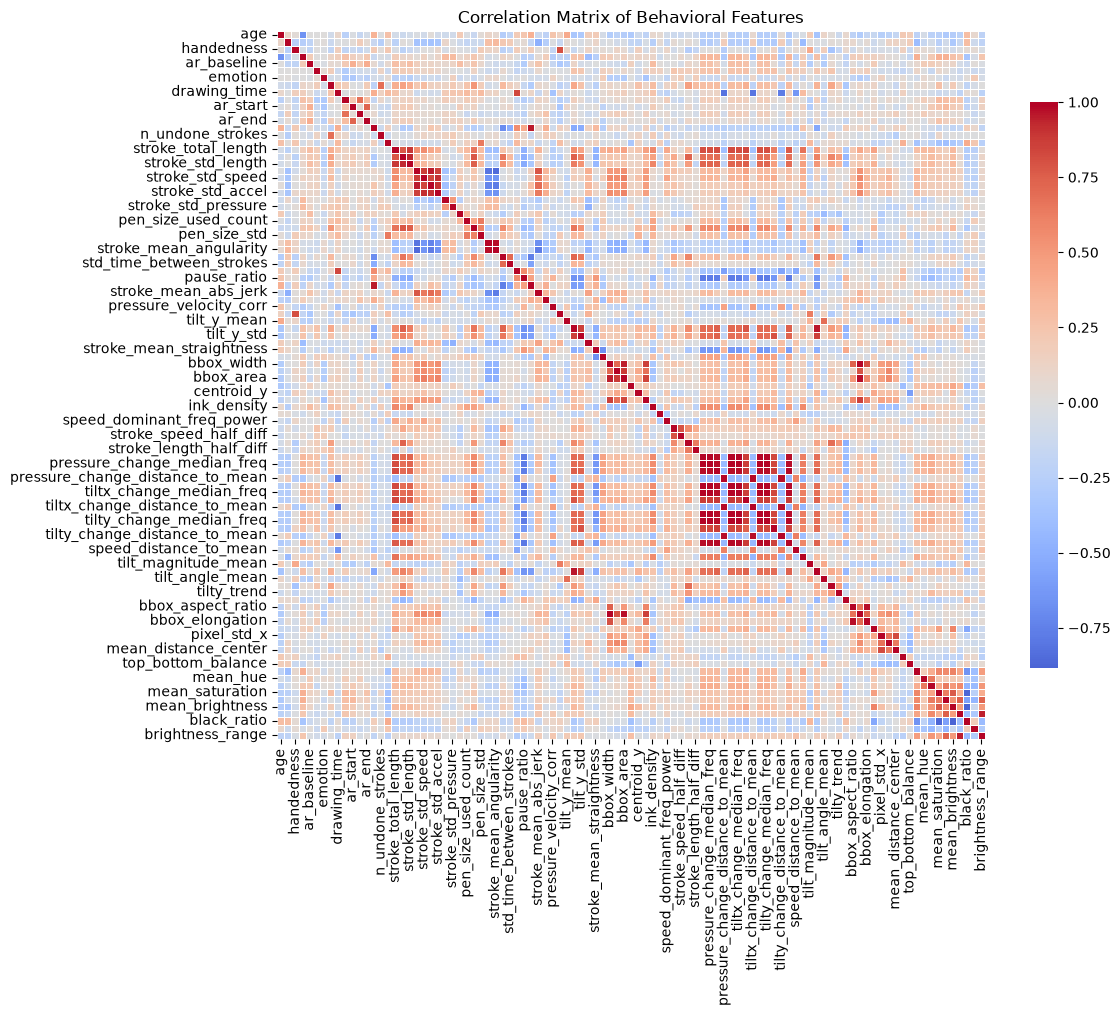

In [4]:
exclude_columns = ["participant_id", "emotion_name", "emotion_3_way", "emotion_3_way_arousal"]

# Select behavioral features only
behavioral_df = features_df.drop(columns=exclude_columns, errors="ignore")
corr_matrix = behavioral_df.corr(method="pearson")

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Behavioral Features")
plt.savefig("figures/correlation_matrix_full_set.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()


### Remove Highly Correlated Pairs

In [5]:
# Find high correlations
high_corr_pairs = []

threshold = 0.85

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((col1, col2, value))

# Print results
print("\nHighly correlated feature pairs (|r| > 0.85):")
for pair in high_corr_pairs:
    print(f"{pair[0]}  <->  {pair[1]}  : r = {pair[2]:.3f}")



Highly correlated feature pairs (|r| > 0.85):
stroke_std_length  <->  stroke_total_length  : r = 0.886
stroke_std_length  <->  stroke_mean_length  : r = 0.927
stroke_std_speed  <->  stroke_mean_speed  : r = 0.872
stroke_mean_accel  <->  stroke_mean_speed  : r = 0.956
stroke_std_accel  <->  stroke_mean_speed  : r = 0.862
stroke_std_accel  <->  stroke_std_speed  : r = 0.916
stroke_std_accel  <->  stroke_mean_accel  : r = 0.904
stroke_mean_angularity  <->  stroke_mean_curvature  : r = 0.972
stroke_frequency  <->  n_strokes  : r = 0.951
tilt_y_std  <->  tilt_x_std  : r = 0.864
bbox_area  <->  bbox_width  : r = 0.945
bbox_area  <->  bbox_height  : r = 0.882
spatial_spread  <->  bbox_width  : r = 0.860
pressure_change_median_freq  <->  pressure_change_bandwidth  : r = 0.999
pressure_change_peaks_per_sec  <->  pressure_change_bandwidth  : r = 0.973
pressure_change_peaks_per_sec  <->  pressure_change_median_freq  : r = 0.971
tiltx_change_bandwidth  <->  pressure_change_bandwidth  : r = 0.999


Dropping 'pressure_change_peaks_per_sec' (degree=9, correlated with: ['pressure_change_bandwidth', 'pressure_change_median_freq', 'tiltx_change_bandwidth', 'tiltx_change_median_freq', 'tiltx_change_peaks_per_sec', 'tilty_change_bandwidth', 'tilty_change_median_freq', 'tilty_change_peaks_per_sec', 'speed_peaks_per_sec'])
Dropping 'tiltx_change_peaks_per_sec' (degree=7, correlated with: ['pressure_change_bandwidth', 'pressure_change_median_freq', 'tiltx_change_bandwidth', 'tiltx_change_median_freq', 'tilty_change_bandwidth', 'tilty_change_median_freq', 'speed_peaks_per_sec'])
Dropping 'tiltx_change_bandwidth' (degree=6, correlated with: ['pressure_change_bandwidth', 'pressure_change_median_freq', 'tiltx_change_median_freq', 'tilty_change_bandwidth', 'tilty_change_median_freq', 'speed_peaks_per_sec'])
Dropping 'pressure_change_bandwidth' (degree=5, correlated with: ['pressure_change_median_freq', 'tiltx_change_median_freq', 'tilty_change_bandwidth', 'tilty_change_median_freq', 'speed_peak

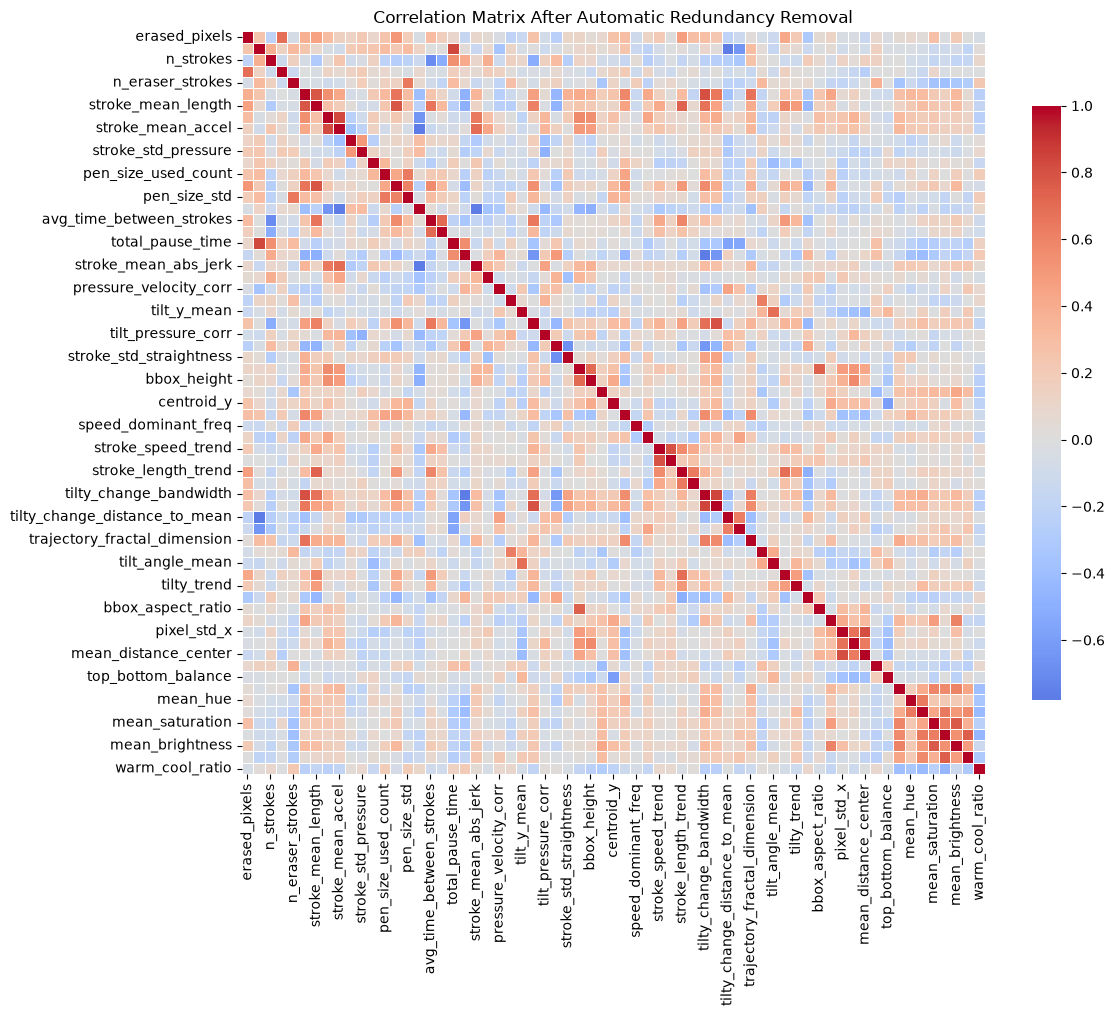


Dropped features (23):
  - pressure_change_peaks_per_sec
  - tiltx_change_peaks_per_sec
  - tiltx_change_bandwidth
  - pressure_change_bandwidth
  - tiltx_change_median_freq
  - tilty_change_median_freq
  - stroke_mean_speed
  - bbox_area
  - pressure_change_median_freq
  - tilt_x_std
  - stroke_std_length
  - bbox_diagonal
  - tiltx_change_distance_to_mean
  - black_ratio
  - stroke_std_accel
  - speed_peaks_per_sec
  - tilt_magnitude_std
  - spatial_spread
  - stroke_mean_curvature
  - pressure_change_distance_to_mean
  - stroke_frequency
  - brightness_range
  - bbox_elongation

Retained features (65):
  - erased_pixels
  - drawing_time
  - n_strokes
  - n_undone_strokes
  - n_eraser_strokes
  - stroke_total_length
  - stroke_mean_length
  - stroke_std_speed
  - stroke_mean_accel
  - stroke_mean_pressure
  - stroke_std_pressure
  - stroke_pressure_slope
  - pen_size_used_count
  - pen_size_mean
  - pen_size_std
  - stroke_mean_angularity
  - avg_time_between_strokes
  - std_time_be

In [ ]:
def auto_remove_correlated_features(df, exclude_columns=None, threshold=0.85, method="pearson", verbose=True):
    exclude_columns = exclude_columns or []
    behavioral_df = df.drop(columns=exclude_columns, errors="ignore")
    behavioral_df = behavioral_df.select_dtypes(include=[np.number])

    working_df = behavioral_df.copy()
    dropped_features = []

    while True:
        corr_matrix = working_df.corr(method=method)

        # find all pairs above threshold
        high_corr_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i):
                if abs(corr_matrix.iloc[i, j]) > threshold:
                    col1 = corr_matrix.columns[i]
                    col2 = corr_matrix.columns[j]
                    value = corr_matrix.iloc[i, j]
                    high_corr_pairs.append((col1, col2, value))

        if not high_corr_pairs:
            break

        # build a graph: nodes = features, edges = high-correlation pairs
        G = nx.Graph()
        G.add_nodes_from(working_df.columns)
        for col1, col2, _ in high_corr_pairs:
            G.add_edge(col1, col2)

        # drop the node with the highest degree (most redundant connections);
        # break ties by dropping the one with higher mean |correlation|
        # across the whole current feature set (more generically redundant)
        degrees = dict(G.degree())
        max_degree = max(degrees.values())
        candidates = [f for f, d in degrees.items() if d == max_degree]

        if len(candidates) > 1:
            mean_abs_corr = corr_matrix.abs().mean()
            candidates.sort(key=lambda f: mean_abs_corr[f], reverse=True)

        feature_to_drop = candidates[0]

        if verbose:
            connected_to = list(G.neighbors(feature_to_drop))
            print(f"Dropping '{feature_to_drop}' (degree={max_degree}, "
                  f"correlated with: {connected_to})")

        working_df = working_df.drop(columns=[feature_to_drop])
        dropped_features.append(feature_to_drop)

    if verbose:
        print(f"\nTotal features dropped: {len(dropped_features)}")
        print(f"Features remaining: {working_df.shape[1]}")
        if len(high_corr_pairs) == 0 and len(dropped_features) == 0:
            print("No highly correlated pairs found — nothing removed.")

    return working_df, dropped_features, working_df.corr(method=method)


# --- Usage ---
non_features = [
    "participant_id", "emotion_name", "handedness", "age", "gender",
    "emotion", "round", "val_start", "ar_start", "val_end", "ar_end",
    "val_baseline", "ar_baseline", "emotion_3_way", "emotion_3_way_arousal"
]

reduced_df, dropped_features, final_corr_matrix = auto_remove_correlated_features(
    features_df, exclude_columns=non_features, threshold=0.85
)

# Visualize the final, decorrelated matrix
plt.figure(figsize=(12, 10))
sns.heatmap(final_corr_matrix, cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix After Automatic Redundancy Removal")
plt.savefig("figures/correlation_matrix_auto_reduced.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

print(f"\nDropped features ({len(dropped_features)}):")
for f in dropped_features:
    print(f"  - {f}")

print(f"\nRetained features ({reduced_df.shape[1]}):")
for f in reduced_df.columns:
    print(f"  - {f}")
    
exclude_columns = non_features + dropped_features

### Stability Selection

In [ ]:
# Define classifiers
classifiers = [
    {
        'name': "LogisticRegression",
        'model': LogisticRegression(
            max_iter=10000,
            class_weight="balanced",
            l1_ratio=0.0,
            C=1,
        ),
        'use_importance': False
    },
    {
        'name': "LinearSVM",
        'model': SVC(
            kernel="linear",
            probability=True,     # needed for ROC-AUC
            decision_function_shape="ovr"
        ),
        'use_importance': False
    },
    {
        'name': "RandomForest",
        'model': RandomForestClassifier(
        n_estimators=200,
        max_depth=3,
        min_samples_leaf=3,
        random_state=0,
        ),
        'use_importance': True
    },
    {
        'name': "GradientBoosting",
        'model': GradientBoostingClassifier(
            n_estimators=100,
            max_depth=1,
            learning_rate=0.05,
            subsample=0.5,
            random_state=0,
            min_samples_leaf=3
        ),
        'use_importance': True,
    },
]


In [9]:
selector = VarianceThreshold(threshold=0.01)  # tune based on your scaled features
X = features_df.drop(columns=exclude_columns)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

threshold=0.01
selector = VarianceThreshold(threshold=threshold)
X_filtered = selector.fit_transform(X_scaled)
kept_cols = X_scaled.columns[selector.get_support()]
dropped_cols = X_scaled.columns[~selector.get_support()]
if len(dropped_cols) > 0:
    print(f"Dropped {len(dropped_cols)} near-zero-variance features: {list(dropped_cols)}")
else:
    print("No features had near-zero-variance!")
X_composite_filtered = pd.DataFrame(X_filtered, columns=kept_cols, index=X.index)


No features had near-zero-variance!


In [10]:
def stability_selection(X, y, groups, model, top_k=None, use_importances=True, non_zero=False):
    logo = LeaveOneGroupOut()
    n_folds = logo.get_n_splits(X, y, groups)
    selection_counts = defaultdict(int)

    for train_idx, _ in logo.split(X, y, groups):
        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]

        scaler_fold = StandardScaler()
        X_train_scaled = scaler_fold.fit_transform(X_train)
        model.fit(X_train_scaled, y_train)
        
        if use_importances:
            importances = model.feature_importances_
        else:
            importances = np.max(model.coef_, axis=0)

        if top_k is not None:
            # select the top_k most important features this fold
            threshold_val = np.sort(importances)[-top_k]
            nonzero_mask = importances >= threshold_val
        elif non_zero:    
            nonzero_mask = np.any(importances != 0, axis=0)
        else:
            # default: above-average importance for this fold
            # equivalent to: top_k = features // 2; here 26
            nonzero_mask = importances >= np.mean(importances)
        
        for col, selected in zip(X.columns, nonzero_mask):
            if selected:
                selection_counts[col] += 1

    stability_df = pd.DataFrame({
        "feature": list(X.columns),
        "n_folds_selected": [selection_counts.get(c, 0) for c in X.columns],
        "fraction_folds_selected": [selection_counts.get(c, 0) / n_folds for c in X.columns]
    }).sort_values("fraction_folds_selected", ascending=False)

    return stability_df

In [11]:
# Prepare data
y_5_way = features_df["emotion_name"]
y_3_way = features_df["emotion_3_way"]
groups = features_df["participant_id"]

# Define Validation method
# Leave-One-Group-Out Cross Validation (LOGO CV)
# -> train on n-1 participants, test on 1 participant, repeat n times. Group = 1 participant with 2 conditions
logo = LeaveOneGroupOut()

In [12]:
THRESHOLD = 0.6
for classifier in classifiers:
    model = classifier['model']
    use_importance = classifier['use_importance']
    
    stability_3_way = stability_selection(
        X_composite_filtered, y_3_way, groups, model, use_importances=use_importance, top_k=8
    )
    selected_features = stability_3_way[stability_3_way['fraction_folds_selected'] >= THRESHOLD]
    classifier['features_3_way'] = list(selected_features['feature'])

    stability_5_way = stability_selection(
        X_composite_filtered, y_5_way, groups, model, use_importances=use_importance, top_k=8
    )
    selected_features = stability_5_way[stability_5_way['fraction_folds_selected'] >= THRESHOLD]
    classifier['features_5_way'] = list(selected_features['feature'])

c:\Users\Tamara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Tamara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Tamara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Tamara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\

In [13]:
for classifier in classifiers:
    name = classifier['name']
    n_3w = len(classifier['features_3_way'])
    n_5w = len(classifier['features_5_way'])

    print(f"{name}: 3W features: {n_3w}; 5W features: {n_5w}")

LogisticRegression: 3W features: 9; 5W features: 7
LinearSVM: 3W features: 8; 5W features: 8
RandomForest: 3W features: 5; 5W features: 7
GradientBoosting: 3W features: 7; 5W features: 6


## Classification Models

Here we test how well models can predict emotion labels ('excitement', 'anger', 'sadness', 'contentment', and 'neutral').

### Multiclass Classification

Tests all classifiers for accuracy

In [ ]:
def multi_class_classification(X, y, groups, group_labels, name, clf, prefix=""):
    # Setup Pipeline and standardizer
    pipeline = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    y_true = []
    y_pred = []
    y_proba = []  # will hold full probability matrix rows

    fold_importances = []

    # Train and test
    for train_idx, test_idx in logo.split(X, y, groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_test)
        probas = pipeline.predict_proba(X_test)  # shape (n_samples, n_classes)

        y_true.extend(y_test)
        y_pred.extend(preds)
        y_proba.extend(probas)  # list of per-sample probability arrays

        # --- permutation importance on test fold ---
        result = permutation_importance(
            pipeline,
            X_test,
            y_test,
            n_repeats=50,
            random_state=42,
            scoring="accuracy"
        )

        fold_importances.append(result.importances_mean)

    fold_importances = np.array(fold_importances)
    y_proba = np.array(y_proba)  # (n_samples, n_classes)

    # Performance metrics
    acc = accuracy_score(y_true, y_pred)

    # Multiclass ROC-AUC: macro-average, one-vs-rest
    # requires probability estimates for every class, and labels param
    # to make sure the class order matches y_proba's column order
    pipeline_classes = pipeline.named_steps["clf"].classes_
    roc_auc = roc_auc_score(
        y_true,
        y_proba,
        multi_class="ovr",
        average="macro",
        labels=pipeline_classes
    )

    cm = confusion_matrix(y_true, y_pred)

    # Permutation test (how much the model is better than random chance)
    score, perm_scores, pvalue = permutation_test_score(
        pipeline,
        X,
        y,
        groups=groups,
        cv=logo,
        scoring="accuracy",
        n_permutations=1000,
        n_jobs=-1
    )
    
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    micro_f1 = f1_score(y_true, y_pred, average='micro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')

    results = {"Classifier": name, "Accuracy": acc, "ROC_AUC_macro": roc_auc, "Permutation_p": pvalue, "macro f1": macro_f1}

    print(f"\n{name}")
    print("Confusion Matrix:")
    print(cm)
    print(f"Accuracy: {acc:.3f}")
    print(f"ROC-AUC (macro OVR): {roc_auc:.3f}")
    print(f"Permutation p-value: {pvalue:.4f}")
    print(f"F1 Sores:\n\tWeighted: {weighted_f1:.3f}\n\tMacro: {macro_f1:.3f}\n\tMicro: {micro_f1:.3f}")
    

    disp = ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        cmap="Blues",
        display_labels=group_labels
    )

    ax = disp.ax_
    plt.setp(ax.get_xticklabels(), rotation=0)
    plt.setp(ax.get_yticklabels(), rotation=90, va='center')
    plt.title("Confusion Matrix")
    fig_name_matrix = "figures/" + prefix + name + "_confusion_matrix.pdf"
    plt.savefig(fig_name_matrix, dpi=300, bbox_inches="tight")
    plt.show()

    # Multiclass ROC: one curve per class (one-vs-rest)
    y_true_arr = np.array(y_true)
    plt.figure()
    for i, cls in enumerate(pipeline_classes):
        fpr, tpr, _ = roc_curve((y_true_arr == cls).astype(int), y_proba[:, i])
        class_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {class_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (One-vs-Rest)")
    plt.legend()

    fig_name_roc = "figures/" + prefix + name + "_roc_curve.pdf"
    plt.savefig(fig_name_roc, dpi=300, bbox_inches="tight")
    plt.show()
    
    return results, fold_importances

In [19]:
def print_results(results, all_importances, classifier_names, features):
    # Summary table
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values("Accuracy", ascending=False)

    print("\n=== Classifier Comparison ===")
    print(results_df)


    importance_tables = {}

    for name in classifier_names:
        importances = all_importances[name]

        importance_df = pd.DataFrame({
            "feature": features[name].columns,
            "importance_mean": importances.mean(axis=0),
            "importance_std": importances.std(axis=0)
        })

        importance_df = importance_df.sort_values(
            "importance_mean",
            ascending=False
        )

        importance_tables[name] = importance_df

        print(f"\n=== Feature Importance ({name}) ===")
        print(importance_df.head(10))
    return results_df, importance_tables

### 5-way classification


LogisticRegression
Confusion Matrix:
[[ 5  2  2  1  2]
 [ 2  5  3  1  1]
 [ 0  2 10  1  0]
 [ 3  7  8  6  1]
 [ 5  2  2  4  0]]
Accuracy: 0.347
ROC-AUC (macro OVR): 0.592
Permutation p-value: 0.0030
F1 Sores:
	Weighted: 0.309
	Macro: 0.309
	Micro: 0.347


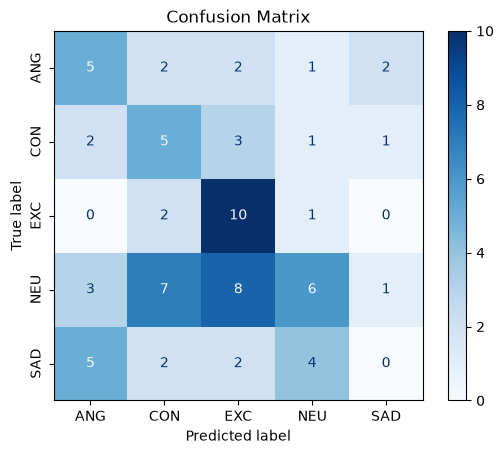

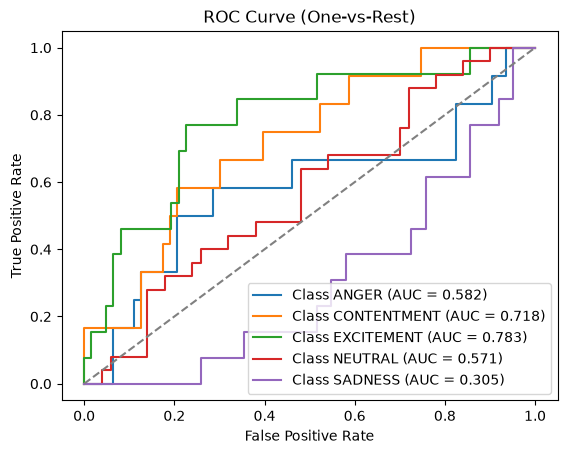

c:\Users\Tamara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Tamara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Tamara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Tamara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\


LinearSVM
Confusion Matrix:
[[ 0  1  3  3  5]
 [ 2  3  2  5  0]
 [ 0  3  6  4  0]
 [ 2  3  3 13  4]
 [ 2  2  1  7  1]]
Accuracy: 0.307
ROC-AUC (macro OVR): 0.518
Permutation p-value: 0.1548
F1 Sores:
	Weighted: 0.281
	Macro: 0.244
	Micro: 0.307


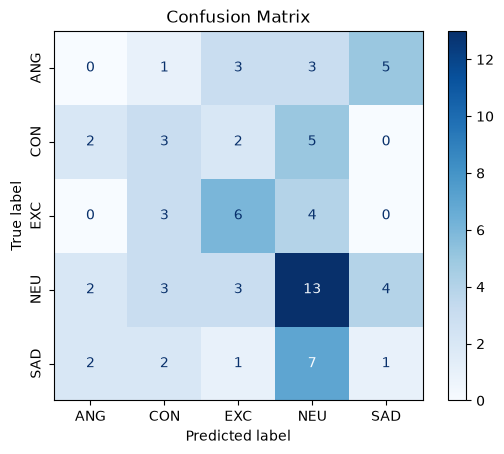

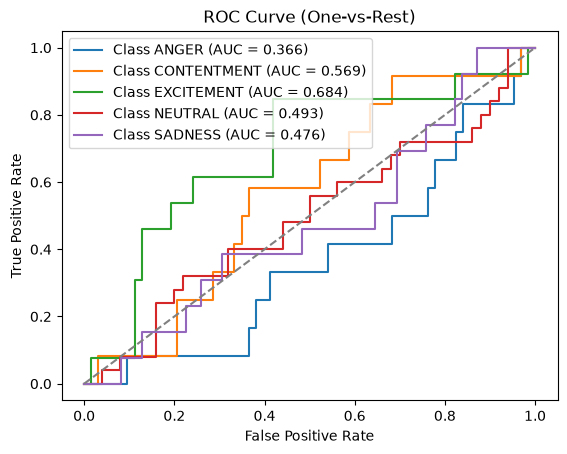


RandomForest
Confusion Matrix:
[[ 0  1  1  9  1]
 [ 1  3  2  6  0]
 [ 0  2  4  7  0]
 [ 1  0  2 22  0]
 [ 1  0  1 11  0]]
Accuracy: 0.387
ROC-AUC (macro OVR): 0.629
Permutation p-value: 0.0090
F1 Sores:
	Weighted: 0.297
	Macro: 0.246
	Micro: 0.387


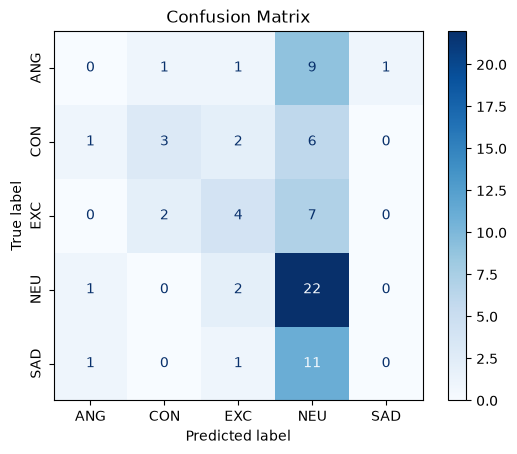

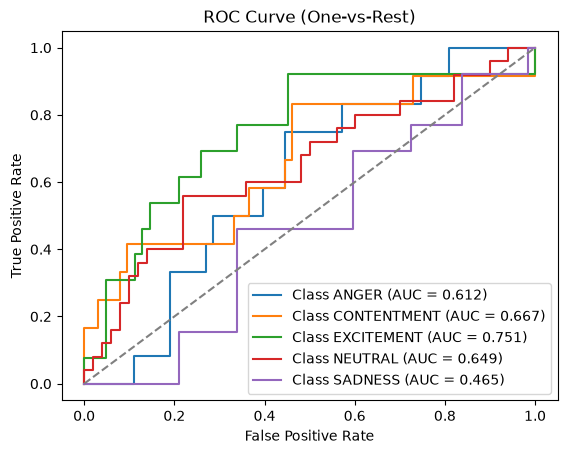


GradientBoosting
Confusion Matrix:
[[ 1  2  0  9  0]
 [ 1  5  1  5  0]
 [ 0  1  6  6  0]
 [ 3  3  5 12  2]
 [ 1  0  2  8  2]]
Accuracy: 0.347
ROC-AUC (macro OVR): 0.636
Permutation p-value: 0.0609
F1 Sores:
	Weighted: 0.328
	Macro: 0.319
	Micro: 0.347


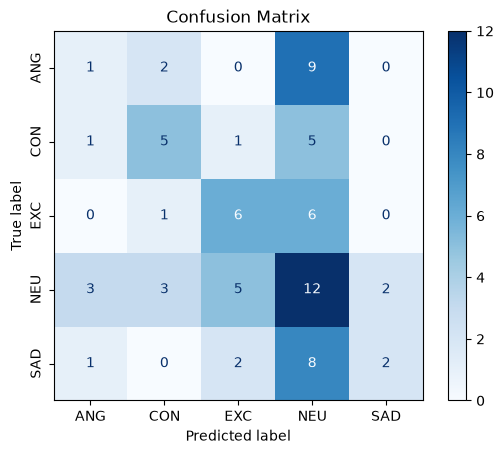

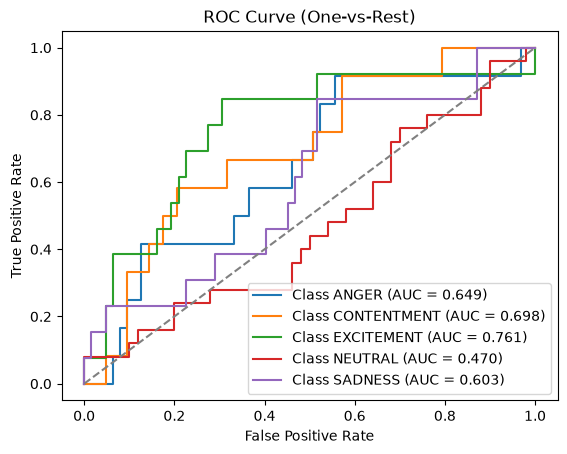


=== Classifier Comparison ===
           Classifier  Accuracy  ROC_AUC_macro  Permutation_p  \
2        RandomForest  0.386667       0.628756       0.008991   
0  LogisticRegression  0.346667       0.591911       0.002997   
3    GradientBoosting  0.346667       0.636361       0.060939   
1           LinearSVM  0.306667       0.517607       0.154845   

                                                  f1  
2  (0.246231884057971, 0.38666666666666666, 0.296...  
0  (0.3091617933723197, 0.3466666666666667, 0.309...  
3  (0.31897261022580714, 0.3466666666666667, 0.32...  
1  (0.24433366023755038, 0.30666666666666664, 0.2...  

=== Feature Importance (LogisticRegression) ===
                   feature  importance_mean  importance_std
0  stroke_std_straightness         0.069867        0.167397
6          warm_cool_ratio         0.046133        0.122244
1       top_bottom_balance         0.043200        0.128791
5      stroke_std_pressure         0.040000        0.140728
2              bbox

In [21]:
five_way = ['ANG', "CON", "EXC", "NEU", "SAD"]
all_results = []
all_importances = {}
classifier_names = [classifier['name'] for classifier in classifiers]
features = {}

for classifier in classifiers:
    X_5_way = features_df[classifier['features_5_way']].select_dtypes(include=[np.number])
    name = classifier['name']
    clf = classifier['model']
    results, importance = multi_class_classification(X_5_way, y_5_way, groups, five_way, name, clf, "5w_")
    all_results.append(results)
    all_importances[name] = importance
    features[name] = X_5_way

results_df, importance_tables = print_results(all_results, all_importances, classifier_names, features)

### 3-way classification


LogisticRegression
Confusion Matrix:
[[15  7  3]
 [ 8 11  6]
 [ 7  5 13]]
Accuracy: 0.520
ROC-AUC (macro OVR): 0.701
Permutation p-value: 0.0010
F1 Sores:
	Weighted: 0.519
	Macro: 0.519
	Micro: 0.520


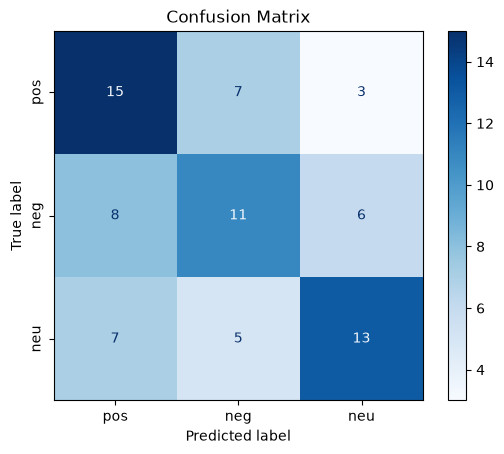

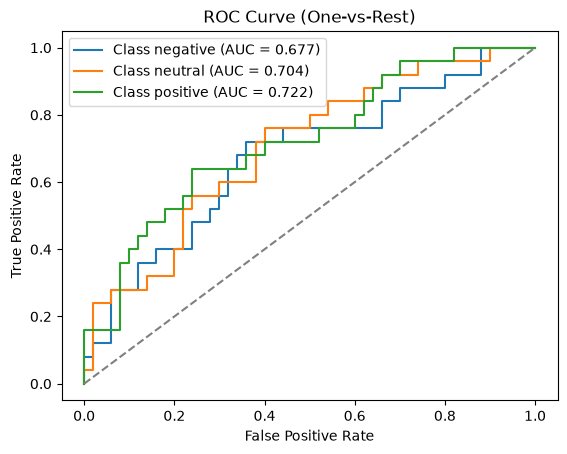

c:\Users\Tamara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Tamara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Tamara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Tamara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\


LinearSVM
Confusion Matrix:
[[16  4  5]
 [ 7 13  5]
 [ 8  7 10]]
Accuracy: 0.520
ROC-AUC (macro OVR): 0.568
Permutation p-value: 0.0020
F1 Sores:
	Weighted: 0.515
	Macro: 0.515
	Micro: 0.520


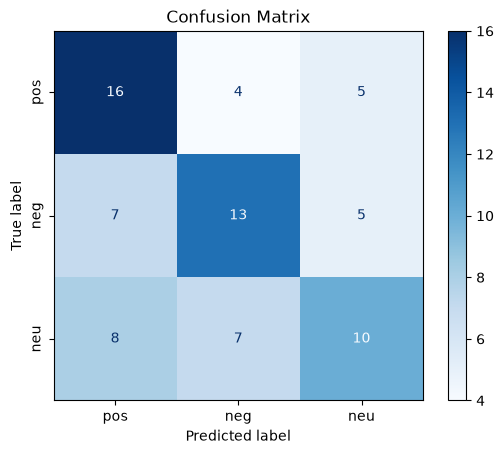

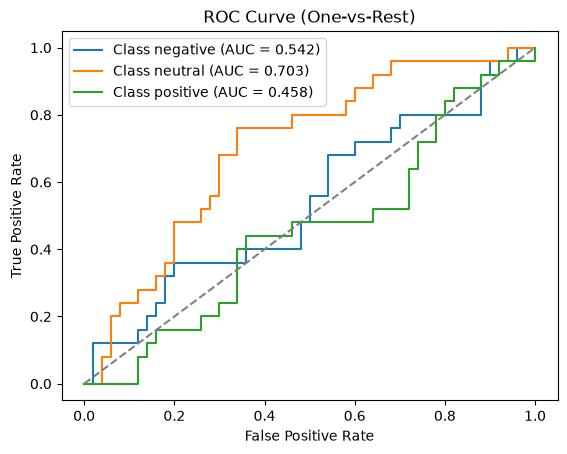


RandomForest
Confusion Matrix:
[[14  6  5]
 [ 5 14  6]
 [ 5  4 16]]
Accuracy: 0.587
ROC-AUC (macro OVR): 0.737
Permutation p-value: 0.0020
F1 Sores:
	Weighted: 0.586
	Macro: 0.586
	Micro: 0.587


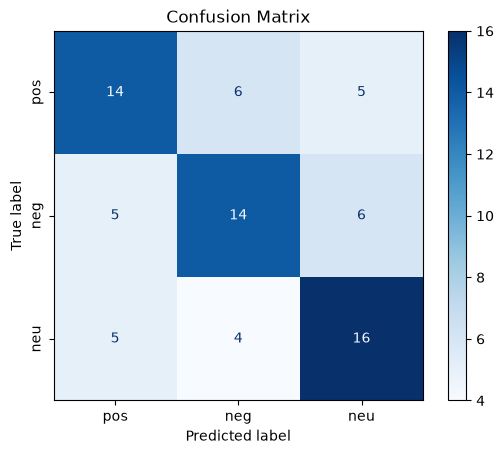

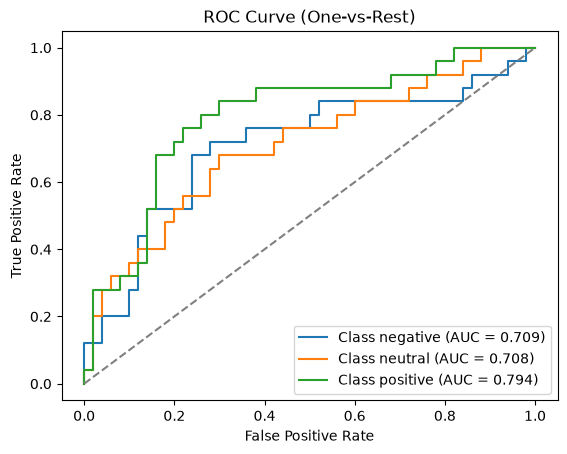


GradientBoosting
Confusion Matrix:
[[15  6  4]
 [ 5 15  5]
 [ 4  4 17]]
Accuracy: 0.627
ROC-AUC (macro OVR): 0.760
Permutation p-value: 0.0010
F1 Sores:
	Weighted: 0.626
	Macro: 0.626
	Micro: 0.627


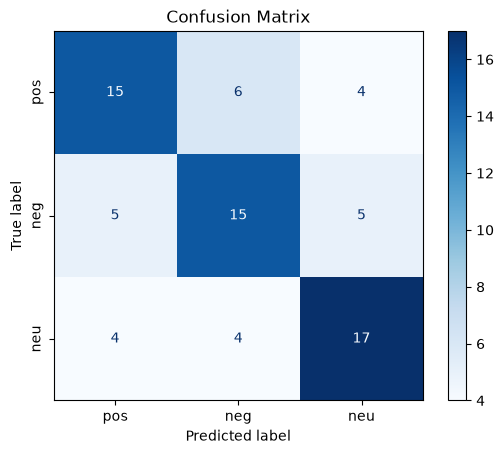

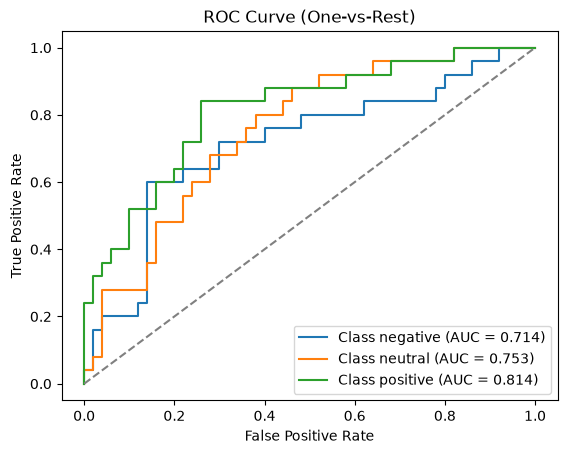


=== Classifier Comparison ===
           Classifier  Accuracy  ROC_AUC_macro  Permutation_p  \
3    GradientBoosting  0.626667       0.760000       0.000999   
2        RandomForest  0.586667       0.736800       0.001998   
1           LinearSVM  0.520000       0.567733       0.001998   
0  LogisticRegression  0.520000       0.700800       0.000999   

                                                  f1  
3  (0.6263038548752834, 0.6266666666666667, 0.626...  
2  (0.5860805860805861, 0.5866666666666667, 0.586...  
1     (0.5154950869236583, 0.52, 0.5154950869236583)  
0      (0.5189931227165269, 0.52, 0.518993122716527)  

=== Feature Importance (LogisticRegression) ===
                   feature  importance_mean  importance_std
2              bbox_height         0.051733        0.145807
6              pixel_std_x         0.040533        0.169306
5              pause_ratio         0.040000        0.100151
3        bbox_aspect_ratio         0.009067        0.110287
1       top_bottom_

In [20]:
three_way = ['pos', 'neg', 'neu']
all_results = []
all_importances = {}
classifier_names = [classifier['name'] for classifier in classifiers]
features = {}

for classifier in classifiers:
    X_3_way = features_df[classifier['features_3_way']].select_dtypes(include=[np.number])
    name = classifier['name']
    clf = classifier['model']
    results, importance = multi_class_classification(X_3_way, y_3_way, groups, three_way, name, clf, "3w_")
    all_results.append(results)
    all_importances[name] = importance
    features[name] = X_3_way

results_df, importance_tables = print_results(all_results, all_importances, classifier_names, features)